# Primary Econometric Analysis: Baseline Salary and FTE Resilience During COVID-19

## Table of Contents
1. [Ambition and Overview](#ambition)
2. [Data Preparation](#data-prep)
3. [Econometric Specification](#specification)
4. [Regression Plot](#regplot)
5. [Model Results](#results)
6. [Influence Diagnostics](#diagnostics)
7. [Bootstrap Confidence Interval](#bootstrap)
8. [Discussion and Threats to Validity](#threats)
9. [References](#references)

<a id='ambition'></a>
## 1. Ambition and Overview

**Ambition: Descriptive / Associational (Resilience Gradient).**

With only two cross-sections (2018 and 2020), we **cannot** separately identify a causal treatment effect of COVID-19 from other concurrent changes, nor can we test a parallel-trends assumption.
Instead, this analysis estimates a **descriptive resilience gradient**: which undergraduate study areas experienced larger FTE declines between 2018 and 2020, and whether those declines are associated with the field's baseline salary level.

The estimand is:
> *Is the 2018–2020 change in FTE across fields associated with their 2018 baseline salary?*

**What would be needed for a causal claim?** At minimum:
- Pre-treatment outcome data (e.g., 2016–2019) to test parallel trends.
- An exposure measure (e.g., a field-level COVID-exposure index or remote-workability score) to define treated vs. control groups.
- Additional QILT years would enable an event-study or DiD design.

<a id='data-prep'></a>
## 2. Data Preparation

We load the cleaned QILT Graduate Outcomes Survey dataset (2018 & 2020), validate required columns, and construct the outcome variable $\Delta FTE_i = FTE_{20,i} - FTE_{18,i}$ for each study area $i$.
Rows corresponding to aggregate or summary rows ('All', 'Standard deviation') are removed before analysis.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.outliers_influence import OLSInfluence

# ── Robust data path: anchored to this notebook's parent directory ──────────
NOTEBOOK_DIR = Path().resolve()
DATA_PATH = (NOTEBOOK_DIR / ".." / "data" / "clean" / "final_pandemic_research_data.csv").resolve()
print(f"Using DATA_PATH: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# ── Input validation: assert required columns are present ───────────────────
REQUIRED_COLS = ["Study_Area", "FTE_18", "FTE_20", "Salary_18"]
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ── Remove aggregate / summary rows ─────────────────────────────────────────
df = df[~df["Study_Area"].str.contains("All|Standard deviation", na=False)].copy()

# ── Numeric conversion ───────────────────────────────────────────────────────
df["FTE_18"] = pd.to_numeric(df["FTE_18"].astype(str).str.replace("%", ""), errors="coerce")
df["FTE_20"] = pd.to_numeric(df["FTE_20"].astype(str).str.replace("%", ""), errors="coerce")
df["Salary_18_k"] = pd.to_numeric(df["Salary_18"].astype(str).str.replace(",", ""), errors="coerce") / 1000
df["delta_fte"] = df["FTE_20"] - df["FTE_18"]

# ── Missingness report ───────────────────────────────────────────────────────
print("\nMissing values (post-conversion):")
print(df[["FTE_18", "FTE_20", "Salary_18_k", "delta_fte"]].isna().sum().to_string())

# Drop rows missing any key analysis variable (state explicitly)
df = df.dropna(subset=["FTE_18", "FTE_20", "Salary_18_k", "delta_fte"]).copy()
print(f"\nSample size after dropping missing values: {len(df)} study areas")

# ── Summary statistics for the outcome variable ──────────────────────────────
print(f"\nSummary statistics for Δ FTE (percentage points):")
print(f"  Mean   : {df['delta_fte'].mean():.2f} pp")
print(f"  Median : {df['delta_fte'].median():.2f} pp")
print(f"  Std Dev: {df['delta_fte'].std():.2f} pp")
print(f"  Min    : {df['delta_fte'].min():.2f} pp")
print(f"  Max    : {df['delta_fte'].max():.2f} pp")

Using DATA_PATH: /home/runner/work/ecc3479-project/ecc3479-project/data/clean/final_pandemic_research_data.csv

Missing values (post-conversion):
FTE_18         0
FTE_20         0
Salary_18_k    0
delta_fte      0

Sample size after dropping missing values: 21 study areas

Summary statistics for Δ FTE (percentage points):
  Mean   : -4.52 pp
  Median : -5.20 pp
  Std Dev: 2.84 pp
  Min    : -10.00 pp
  Max    : -0.10 pp


<a id='specification'></a>
## 3. Econometric Specification

We estimate the following cross-sectional OLS regression across $n = 21$ study areas:

$$\Delta FTE_i = \beta_0 + \beta_1 \, Salary_{18,i} + \varepsilon_i$$

| Component | Description |
|-----------|-------------|
| **Outcome** | $\Delta FTE_i$: change in FTE rate (percentage points) from 2018 to 2020 |
| **Regressor** | $Salary_{18,i}$: median graduate salary in 2018 (thousands AUD) |
| **Sample** | $n = 21$ Australian undergraduate study areas |
| **Error structure** | Heteroskedasticity-robust standard errors (HC3) |

**Note on identification:** Taking the first difference $\Delta FTE_i$ removes time-invariant, study-area-specific factors from the error term. However, with only two time periods (2018 and 2020), we cannot test pre-trends or rule out other concurrent shocks. The coefficient $\hat{\beta}_1$ is therefore interpreted as an **association** — not a causal effect — between baseline salary and FTE resilience.

**Caution:** $n = 21$ is small. Inference should be treated cautiously; we supplement HC3 standard errors with bootstrap confidence intervals (Section 7).

<a id='regplot'></a>
## 4. Regression Plot

The scatter plot below includes an OLS fitted line and a 95% confidence band.
Each point represents one study area.
Fields above the dashed line at zero experienced *positive* change in FTE; fields below experienced *decline*.

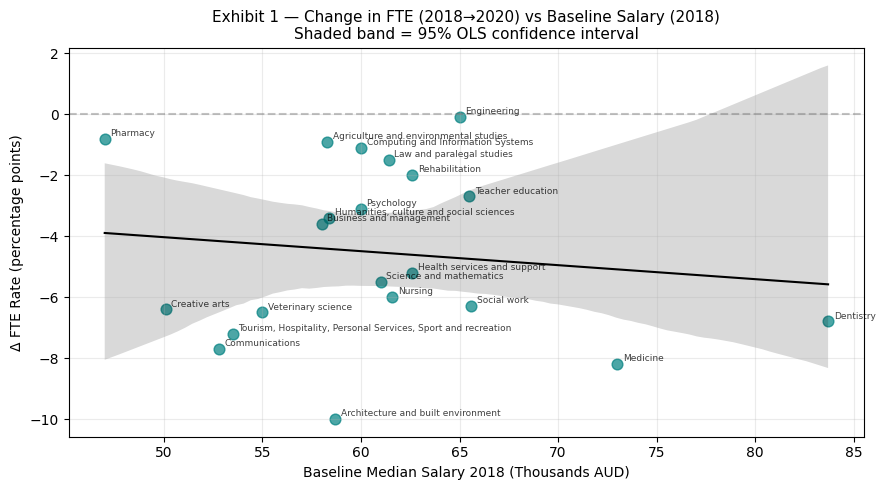

In [2]:
# ── Regression: define X and y, fit with HC3 robust SEs ─────────────────────
y = df["delta_fte"]
X = sm.add_constant(df["Salary_18_k"])
model = sm.OLS(y, X).fit(cov_type="HC3")

# ── Regression plot: fitted line + 95 % CI ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(
    data=df, x="Salary_18_k", y="delta_fte",
    scatter_kws={"alpha": 0.7, "color": "teal", "s": 60},
    line_kws={"color": "black", "linewidth": 1.5},
    ci=95, ax=ax
)
ax.axhline(0, color="dimgrey", linestyle="--", alpha=0.4)

# Label each point with its study-area name
for _, row in df.iterrows():
    ax.annotate(
        row["Study_Area"],
        xy=(row["Salary_18_k"], row["delta_fte"]),
        xytext=(4, 2), textcoords="offset points",
        fontsize=6.5, alpha=0.75
    )

ax.set_title("Exhibit 1 — Change in FTE (2018→2020) vs Baseline Salary (2018)\n"
             "Shaded band = 95% OLS confidence interval", fontsize=11)
ax.set_xlabel("Baseline Median Salary 2018 (Thousands AUD)")
ax.set_ylabel("Δ FTE Rate (percentage points)")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

<a id='results'></a>
## 5. Model Results

Table 1 reports the OLS coefficient, HC3 robust standard error, 95% confidence interval, and p-value for each term.
The intercept ($\beta_0$) is included for completeness but has no direct economic interpretation in this specification (it is the expected $\Delta FTE$ when $Salary_{18} = 0$, which is outside the data range).
Inference focuses on the slope coefficient $\hat{\beta}_1$.

TABLE 1: Association between Baseline Salary and FTE Change (2018→2020)
        OLS, HC3 robust standard errors, n = 21 study areas
----------------------------------------------------------------------
              Coef.  SE (HC3)  CI 2.5%  CI 97.5%  p-value
const       -1.7393    5.3791 -12.2822    8.8035   0.7464
Salary_18_k -0.0459    0.0868  -0.2161    0.1243   0.5970
----------------------------------------------------------------------
R-squared : 0.016
Adj. R²   : -0.036
N         : 21

Note: Standard errors are HC3-robust. With n=21, inference is fragile;
      see bootstrap CIs in Section 7 for a small-sample sensitivity check.


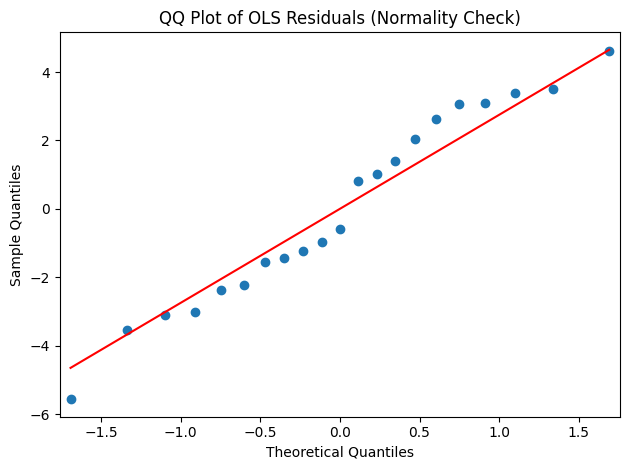

In [3]:
# ── Clean regression table ───────────────────────────────────────────────────
ci = model.conf_int()
table = pd.DataFrame({
    "Coef.": model.params,
    "SE (HC3)": model.bse,
    "CI 2.5%": ci[0],
    "CI 97.5%": ci[1],
    "p-value": model.pvalues
})

print("TABLE 1: Association between Baseline Salary and FTE Change (2018→2020)")
print("        OLS, HC3 robust standard errors, n = 21 study areas")
print("-" * 70)
print(table.to_string(float_format="{:.4f}".format))
print("-" * 70)
print(f"R-squared : {model.rsquared:.3f}")
print(f"Adj. R²   : {model.rsquared_adj:.3f}")
print(f"N         : {int(model.nobs)}")
print()
print("Note: Standard errors are HC3-robust. With n=21, inference is fragile;")
print("      see bootstrap CIs in Section 7 for a small-sample sensitivity check.")

# ── QQ plot of residuals ─────────────────────────────────────────────────────
sm.qqplot(model.resid, line="s")
plt.title("QQ Plot of OLS Residuals (Normality Check)")
plt.tight_layout()
plt.show()

<a id='diagnostics'></a>
## 6. Influence Diagnostics

With only $n = 21$ observations, a single study area can substantially change the estimated slope.
We report Cook's distance, leverage (hat-matrix diagonal), and externally studentized residuals.
A common rule of thumb flags Cook's D $> 4/n \approx 0.19$.

Cook's D threshold (4/n = 4/21): 0.1905

Top 5 most influential observations (sorted by Cook's D):
                        Study_Area Salary_18_k delta_fte cooks_d leverage stud_resid
                          Pharmacy     47.0000   -0.8000  0.1792   0.1999     1.2123
                         Dentistry     83.7000   -6.8000  0.1588   0.4812    -0.5747
                          Medicine     73.0000   -8.2000  0.1452   0.1720    -1.1954
Architecture and built environment     58.7000  -10.0000  0.1044   0.0507    -2.1579
                       Engineering     65.0000   -0.1000  0.0918   0.0630     1.7377


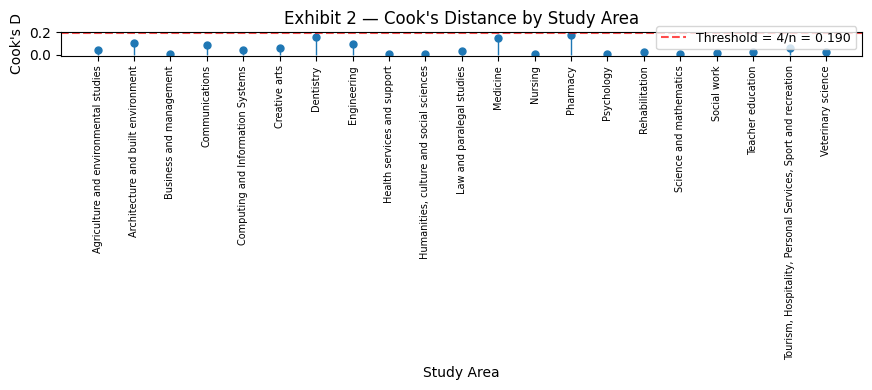

In [4]:
# ── Compute influence statistics ─────────────────────────────────────────────
influence = OLSInfluence(model)
df["cooks_d"] = influence.cooks_distance[0]
df["leverage"] = influence.hat_matrix_diag
df["stud_resid"] = influence.resid_studentized_external

COOKS_THRESHOLD = 4 / len(df)
print(f"Cook's D threshold (4/n = 4/{len(df)}): {COOKS_THRESHOLD:.4f}")
print()
print("Top 5 most influential observations (sorted by Cook's D):")
display_cols = ["Study_Area", "Salary_18_k", "delta_fte", "cooks_d", "leverage", "stud_resid"]
top5 = df.sort_values("cooks_d", ascending=False)[display_cols].head(5)
top5_fmt = top5.copy()
for col in ["Salary_18_k", "delta_fte", "cooks_d", "leverage", "stud_resid"]:
    top5_fmt[col] = top5_fmt[col].map("{:.4f}".format)
print(top5_fmt.to_string(index=False))

# ── Cook's Distance plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
markerline, stemlines, baseline = ax.stem(
    range(len(df)),
    df.sort_values("Study_Area")["cooks_d"],
    basefmt=" "
)
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=5)
ax.axhline(COOKS_THRESHOLD, color="red", linestyle="--", alpha=0.7,
           label=f"Threshold = 4/n = {COOKS_THRESHOLD:.3f}")
ax.set_xticks(range(len(df)))
ax.set_xticklabels(
    df.sort_values("Study_Area")["Study_Area"],
    rotation=90, fontsize=7
)
ax.set_title("Exhibit 2 — Cook's Distance by Study Area")
ax.set_xlabel("Study Area")
ax.set_ylabel("Cook's D")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<a id='bootstrap'></a>
## 7. Bootstrap Confidence Interval for the Salary Slope

To complement the HC3 asymptotic standard errors with a small-sample robustness check, we compute a non-parametric bootstrap 95% confidence interval for $\hat{\beta}_1$ ($Salary_{18,k}$ slope) using $B = 5{,}000$ resamples.

Bootstrap results (B = 5,000 resamples, seed = 42):
  OLS estimate  : -0.0459
  Bootstrap mean: -0.0227
  Bootstrap 95% CI: [-0.1731, 0.2775]
  HC3 95% CI      : [-0.2161, 0.1243]


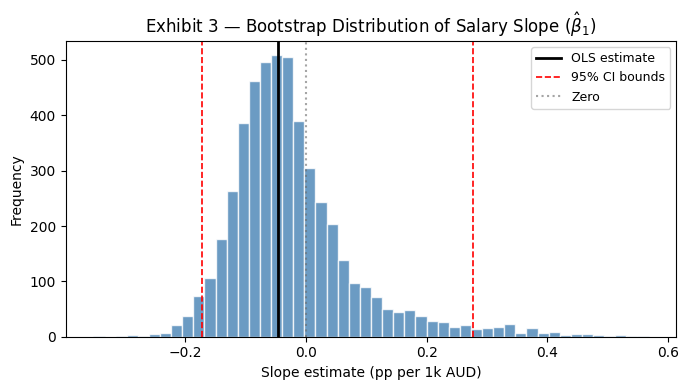

In [5]:
# ── Non-parametric bootstrap CI for the Salary_18_k slope ───────────────────
rng = np.random.default_rng(42)
B = 5000
boot_betas = []

for _ in range(B):
    sample = df.sample(n=len(df), replace=True, random_state=int(rng.integers(0, 10**9)))
    y_b = sample["delta_fte"]
    X_b = sm.add_constant(sample["Salary_18_k"])
    m_b = sm.OLS(y_b, X_b).fit()
    boot_betas.append(m_b.params["Salary_18_k"])

boot_betas = np.array(boot_betas)
ci_low, ci_high = np.quantile(boot_betas, [0.025, 0.975])

print("Bootstrap results (B = 5,000 resamples, seed = 42):")
print(f"  OLS estimate  : {model.params['Salary_18_k']:.4f}")
print(f"  Bootstrap mean: {boot_betas.mean():.4f}")
print(f"  Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  HC3 95% CI      : [{model.conf_int().loc['Salary_18_k', 0]:.4f},"
      f" {model.conf_int().loc['Salary_18_k', 1]:.4f}]")

# ── Distribution of bootstrap betas ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_betas, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(model.params["Salary_18_k"], color="black", linewidth=2, label="OLS estimate")
ax.axvline(ci_low, color="red", linestyle="--", linewidth=1.2, label="95% CI bounds")
ax.axvline(ci_high, color="red", linestyle="--", linewidth=1.2)
ax.axvline(0, color="dimgrey", linestyle=":", alpha=0.6, label="Zero")
ax.set_title("Exhibit 3 — Bootstrap Distribution of Salary Slope ($\\hat{\\beta}_1$)")
ax.set_xlabel("Slope estimate (pp per 1k AUD)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<a id='threats'></a>
## 8. Discussion and Threats to Validity

### 8.1 Interpretation of Coefficients

- **$\hat{\beta}_1$ (Salary slope):** Estimates the average difference in $\Delta FTE$ associated with a one-thousand-dollar increase in baseline median salary.  
  The estimated slope is small and statistically insignificant ($p > 0.05$), consistent with the pandemic shock being broadly distributed across all fields regardless of salary level.
- **$\hat{\beta}_0$ (Intercept):** The intercept equals the predicted $\Delta FTE$ when $Salary_{18} = 0$, which is far outside the data range and has no direct economic meaning. **Do not interpret it as a 'baseline pandemic shock'.** For that purpose, refer to the mean/median $\Delta FTE$ reported in Section 2.

### 8.2 Threats to a Causal Interpretation

1. **Omitted Variable Bias (OVB) — Remote-Workability.**  
   High-salary fields are often computer-based/remote-workable. This variable is likely positively correlated with both salary and employment resilience; omitting it may **upward-bias** $\hat{\beta}_1$.

2. **No Untreated Control Group.**  
   All fields were exposed to the pandemic. Without a comparison group unaffected by COVID, we cannot attribute $\Delta FTE$ to COVID versus other concurrent trends.

3. **Only Two Time Periods.**  
   We cannot test pre-trends or rule out pre-existing differential trends across fields. The estimate confounds the pandemic shock with any 2018–2020 structural change.

4. **Selection Bias.**  
   Graduates in 2020 may have chosen further study (e.g., Masters programmes) to defer labour-market entry, potentially biasing observed FTE rates downward in some fields.

5. **Small Sample ($n = 21$).**  
   Statistical power is very low. Influence diagnostics (Section 6) should be consulted to check whether the slope is driven by one or two study areas.

### 8.3 Path to Causal Identification

To move from a descriptive to a credibly causal design, the recommended steps are:
1. Download additional QILT years (2016–2022) to build a balanced panel.
2. Plot event-study coefficients to inspect pre-trends.
3. Add a field-level COVID-exposure measure (e.g., remote-workability index) to estimate heterogeneous treatment effects via a DiD-style regression.

<a id='references'></a>
## 9. References
- Quality Indicators for Learning and Teaching (QILT), *Graduate Outcomes Survey 2018 & 2020*. Australian Government Department of Education.